In [1]:
import numpy as np
import pandas as pd
import datetime
import sklearn
from sklearn.cluster import AgglomerativeClustering, KMeans
import warnings
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from yellowbrick.cluster import KElbowVisualizer
from sklearn.decomposition import PCA
from matplotlib import cm
from sklearn.metrics import silhouette_score
import os
from scipy.cluster.hierarchy import dendrogram, linkage

warnings.filterwarnings("ignore")
np.random.seed(42)


C:\Users\h\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


### Dataset Description:
This dataset was obtained from https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis. It has 2240 customers' personal and shopping preference data.



In [2]:
df = pd.read_csv('marketing_campaign.csv', sep='\t')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [3]:
df.shape

(2240, 29)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

### Missing Values:
Only 'Income' column has missing values. Since income is an important factor influencing people's shopping habits, we will drop the rows that have missing values in that column. 

In [5]:
df.dropna(subset='Income', inplace=True)
df.shape

(2216, 29)

### Cleaning the Data:

In [6]:
df['Z_CostContact'].value_counts()

3    2216
Name: Z_CostContact, dtype: int64

In [7]:
df['Z_Revenue'].value_counts()

11    2216
Name: Z_Revenue, dtype: int64

Two columns Z_Revenue and Z_CostContact have constant values and they are irrelevant. ID column also is not relevant so we will drop all these columns.

In [8]:
df.drop(columns=['Z_Revenue', 'Z_CostContact', 'ID'], inplace=True, axis=1)
df.columns

Index(['Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Response'],
      dtype='object')

### Customers' Age:
'Year_Birth' column has the year the customers were born. We will convert this into age they were when this dataset was obtained which is presumably the last day in the dataset.

In [9]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])
year = df['Dt_Customer'].max().year
year

2014

In [10]:
df['age'] = year - df['Year_Birth']
df['age'].head()

0    57
1    60
2    49
3    30
4    33
Name: age, dtype: int64

In [11]:
df.drop('Year_Birth', inplace=True, axis=1)
df.columns

Index(['Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome',
       'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
       'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3',
       'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2',
       'Complain', 'Response', 'age'],
      dtype='object')

### Date Customers Started Shopping:
'Dt_Customer' holds the date a customer started shopping at that store. We will convert this into the number of days the customer has been shopping at this store.

In [12]:
cust_period=df['Dt_Customer'].max() - df['Dt_Customer']

df['cust_period'] = cust_period.astype('str')
df['cust_period'] = df['cust_period'].apply(lambda x:x.split(" ")[0]).astype(int)
df[['Dt_Customer', 'cust_period']].head()

,Dt_Customer,cust_period
0,2012-04-09,971
1,2014-08-03,125
2,2013-08-21,472
3,2014-10-02,65
4,2014-01-19,321


In [13]:
#Drop Dt_Customer:
df.drop(columns='Dt_Customer', inplace=True)

In [14]:
df.columns

Index(['Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome',
       'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
       'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3',
       'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2',
       'Complain', 'Response', 'age', 'cust_period'],
      dtype='object')

### Marital Status:

In [15]:
df.Marital_Status.value_counts()

Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: Marital_Status, dtype: int64

In [16]:
df['has_partner'] = df['Marital_Status'].apply(lambda x: 1 if x=='Married' or x=='Together' else 0)
df['has_partner'].value_counts()

1    1430
0     786
Name: has_partner, dtype: int64

In [17]:
df.drop(columns='Marital_Status', inplace=True, axis=1)

### Children:
To obtain the number of children under 18 in each home add Kidhome and Teenhome columns:

In [18]:
df.columns

Index(['Education', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines',
       'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Response', 'age', 'cust_period',
       'has_partner'],
      dtype='object')

In [19]:
df['Kidhome'].value_counts()

0    1283
1     887
2      46
Name: Kidhome, dtype: int64

In [20]:
df['children'] = df['Kidhome'] + df['Teenhome']
df['children'].value_counts()

1    1117
0     633
2     416
3      50
Name: children, dtype: int64

In [21]:
#drop Kidhome and Teenhome:
df.drop(columns=['Kidhome','Teenhome'], inplace=True, axis=1)

In [22]:
df.columns

Index(['Education', 'Income', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Response', 'age', 'cust_period',
       'has_partner', 'children'],
      dtype='object')

### Education:
We will group Basic and 2n Cycle as 'grade', Graduation as 'undergraduate' and PhD and Master as 'postgraduate':

In [23]:
df['Education'].value_counts()

Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: Education, dtype: int64

In [24]:
educ = {'Basic':0,'2n Cycle':0,'Graduation':1,'PhD':2,'Master':2}
df['education'] = df['Education'].map(educ)
df.drop('Education', inplace=True, axis=1)
df.education.value_counts()

1    1116
2     846
0     254
Name: education, dtype: int64

### Customers' Expenditures:
Columns 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds' can be combined to obtain the expenditures of the customers.

In [25]:
df['expenditures'] = df[ 'MntWines']+ df['MntFruits']+df['MntMeatProducts']+df['MntFishProducts']+df['MntSweetProducts']+df['MntGoldProds']
df.drop([ 'MntWines', 'MntFruits', 'MntMeatProducts','MntFishProducts', 'MntSweetProducts', 'MntGoldProds'], inplace=True, axis=1)
df.columns

Index(['Income', 'Recency', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Response', 'age', 'cust_period',
       'has_partner', 'children', 'education', 'expenditures'],
      dtype='object')

### Accepted Offers:
Columns 'AcceptedCmpn' gives us information about whether a customer accepted the offer in the nth campaign. Response is whether a customer accepted the offer in the last campaign. We will add these.

In [26]:
df['accepted_offer'] = df['AcceptedCmp3']+df['AcceptedCmp4'] +df['AcceptedCmp5'] +df['AcceptedCmp1']+df['AcceptedCmp2']+df['Response']
df.drop(['AcceptedCmp3','AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Response'], inplace=True, axis=1)

In [27]:
df.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,age,cust_period,has_partner,children,education,expenditures,accepted_offer
0,58138.0,58,3,8,10,4,7,0,57,971,0,0,1,1617,1
1,46344.0,38,2,1,1,2,5,0,60,125,0,2,1,27,0
2,71613.0,26,1,8,2,10,4,0,49,472,1,0,1,776,0
3,26646.0,26,2,2,0,4,6,0,30,65,1,1,1,53,0
4,58293.0,94,5,5,3,6,5,0,33,321,1,1,2,422,0


### Number of Purchases:
We will consolidate all purchases made through different channels.

In [28]:
df['num_purchases'] = df['NumDealsPurchases']+df['NumWebPurchases']+df['NumCatalogPurchases'] +df['NumStorePurchases']
df.drop(columns= ['NumDealsPurchases', 'NumWebPurchases','NumCatalogPurchases', 'NumStorePurchases'], inplace=True, axis=1)
df.head()


,Income,Recency,NumWebVisitsMonth,Complain,age,cust_period,has_partner,children,education,expenditures,accepted_offer,num_purchases
0,58138.0,58,7,0,57,971,0,0,1,1617,1,25
1,46344.0,38,5,0,60,125,0,2,1,27,0,6
2,71613.0,26,4,0,49,472,1,0,1,776,0,21
3,26646.0,26,6,0,30,65,1,1,1,53,0,8
4,58293.0,94,5,0,33,321,1,1,2,422,0,19


### Number of Complains:
Only 21 customers out of 2216 made a complaint in the last two years. Since it is not a very representative feature of customer behavior we will remove that column. 

In [29]:
df['Complain'].value_counts()

0    2195
1      21
Name: Complain, dtype: int64

In [30]:
df.drop('Complain', axis=1, inplace=True)

In [31]:
df.columns = ['income', 'recency', 'numwebvisits','age', 'cust_period', 'has_partner','children','education','expenditures','accepted_offer', 'num_purchases']

### Outliers:

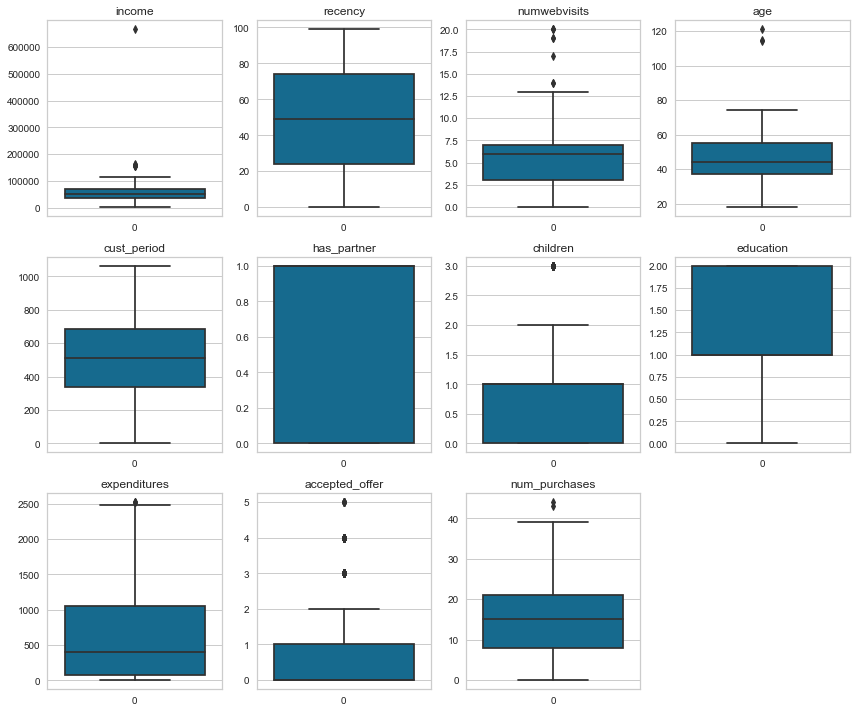

In [32]:
fig, ax = plt.subplots(ncols=4,nrows=3, figsize=(12,10))
ax = ax.ravel()
for i in range(len(df.columns)):
    sns.boxplot(df[df.columns[i]], ax=ax[i])
    ax[i].set_title(df.columns[i])
    ax[11].axis('off')
plt.tight_layout()

The only two outliers that do not make much sense are seen in income and age columns. One data point's income value is more than six hundred thousand dollars and some data points' age values are more than one hundred. We will eliminate these data points

In [33]:
print(df.shape)
df = df[df['age']<100]
df.shape

(2216, 11)


(2213, 11)

In [34]:
print(df.shape)
df=df[df['income']<600000]
df.shape

(2213, 11)


(2212, 11)

## Exploratory Distributions

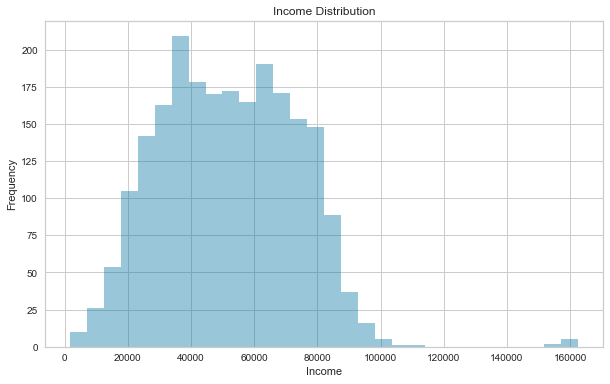

In [35]:
plt.figure(figsize=(10,6))
sns.distplot(df['income'], bins=30, kde=False)
plt.title('Income Distribution')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.show()

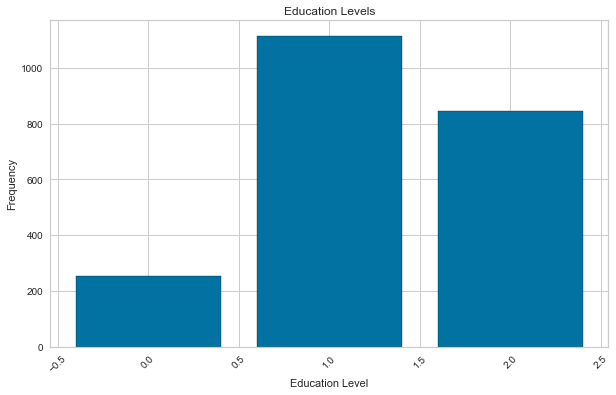

In [36]:
import matplotlib.pyplot as plt

# Count the frequency of each category
education_counts = df['education'].value_counts()

plt.figure(figsize=(10,6))
plt.bar(education_counts.index, education_counts.values, edgecolor='black')
plt.title('Education Levels')
plt.xlabel('Education Level')
plt.ylabel('Frequency')
plt.xticks(rotation=45) # This is to rotate the x-axis labels if they are long
plt.show()

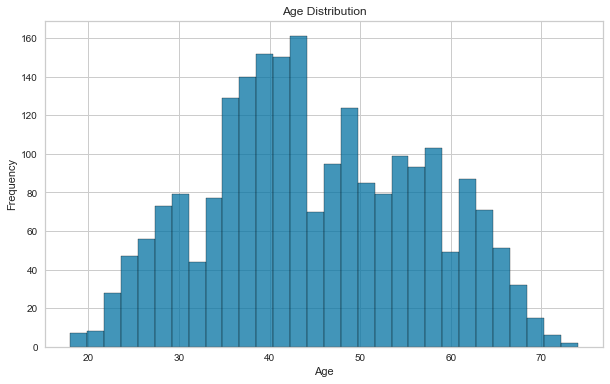

In [37]:
plt.figure(figsize=(10,6))
sns.histplot(df['age'], bins=30, kde=False)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

### Description of final features:


In [38]:
print("""
income: Customer's yearly household income
recency: : Number of days since customer's last purchase
numwebvisits: Number of visits to company\'s website in the last month
cust_period: Date of customer's enrollment with the company (in days)
has_partner: Living with a partner or single
children: Number of children under 18
education: Customer's level of education
expenditures: The amount spent in last 2 years
accepted_offer: Whether the customer accepted a promotion offer
num_purchases: Number of purchases
"""
 )


income: Customer's yearly household income
recency: : Number of days since customer's last purchase
numwebvisits: Number of visits to company's website in the last month
cust_period: Date of customer's enrollment with the company (in days)
has_partner: Living with a partner or single
children: Number of children under 18
education: Customer's level of education
expenditures: The amount spent in last 2 years
accepted_offer: Whether the customer accepted a promotion offer
num_purchases: Number of purchases



### Correlation of Features:

In [39]:
df.corr()

,income,recency,numwebvisits,age,cust_period,has_partner,children,education,expenditures,accepted_offer,num_purchases
income,1.000000,0.007965,-0.650257,0.199977,-0.027892,-0.004803,-0.343529,0.158032,0.792740,0.343150,0.670413
recency,0.007965,1.000000,-0.018965,0.015694,0.030748,-0.000417,0.018062,-0.016135,0.020479,-0.090404,0.007658
numwebvisits,-0.650257,-0.018965,1.000000,-0.120282,0.255436,0.003118,0.415558,-0.052848,-0.498769,-0.126571,-0.314777
age,0.199977,0.015694,-0.120282,1.000000,-0.021057,0.003692,0.092676,0.193320,0.115901,-0.006957,0.181526
cust_period,-0.027892,0.030748,0.255436,-0.021057,1.000000,0.001907,-0.034836,-0.072563,0.138590,0.056206,0.190642
has_partner,-0.004803,-0.000417,0.003118,0.003692,0.001907,1.000000,0.042741,-0.011353,-0.020930,-0.060392,0.004551
children,-0.343529,0.018062,0.415558,0.092676,-0.034836,0.042741,1.000000,0.061240,-0.499931,-0.254040,-0.250195
education,0.158032,-0.016135,-0.052848,0.193320,-0.072563,-0.011353,0.061240,1.000000,0.095419,0.058935,0.095793
expenditures,0.792740,0.020479,-0.498769,0.115901,0.138590,-0.020930,-0.499931,0.095419,1.000000,0.453273,0.756876
accepted_offer,0.343150,-0.090404,-0.126571,-0.006957,0.056206,-0.060392,-0.254040,0.058935,0.453273,1.000000,0.256794


# Scale data

In [40]:
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
df_scaled_2 = df_scaled
df_scaled.head()

,income,recency,numwebvisits,age,cust_period,has_partner,children,education,expenditures,accepted_offer,num_purchases
0,0.287105,0.310353,0.692181,1.018352,1.973583,-1.349603,-1.264598,-0.411675,1.676245,0.617244,1.317945
1,-0.260882,-0.380813,-0.132545,1.274785,-1.665144,-1.349603,1.404572,-0.411675,-0.963297,-0.502808,-1.159273
2,0.913196,-0.795514,-0.544908,0.334530,-0.172664,0.740959,-1.264598,-0.411675,0.280110,-0.502808,0.796425
3,-1.176114,-0.795514,0.279818,-1.289547,-1.923210,0.740959,0.069987,-0.411675,-0.920135,-0.502808,-0.898513
4,0.294307,1.554453,-0.132545,-1.033114,-0.822130,0.740959,0.069987,1.123949,-0.307562,-0.502808,0.535666


# Determining Number of Clusters with KMeans:

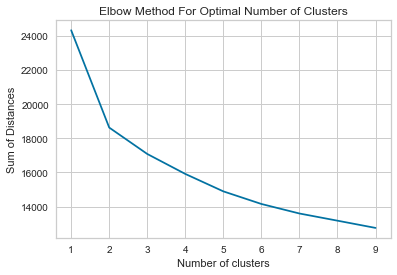

In [41]:
#Manually determining the number of clusters
distances = []
k_values = range(1,10)
for cluster in k_values :
  kmeans = KMeans(n_clusters=cluster)
  kmeans.fit(df_scaled)
  distances.append(kmeans.inertia_)
plt.plot(k_values, distances,'bx-')
plt.xlabel('Number of clusters') 
plt.ylabel('Sum of Distances') 
plt.title('Elbow Method For Optimal Number of Clusters')
plt.show()

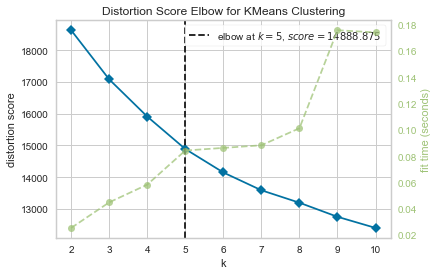

<AxesSubplot: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [42]:
#Using KElbowVisualizer to determine the number of clusters 
auto_elbow = KElbowVisualizer(KMeans(), k=10)
auto_elbow.fit(df_scaled)
auto_elbow.show()

Both methods show that there should be 5 clusters.

### Reducing the Dimension of the Dataset with PCA:

In [43]:
pca = PCA(n_components=3)
reduced_df = pd.DataFrame(pca.fit_transform(df_scaled), columns=(["c1","c2", "c3"]))
reduced_df.describe()


,c1,c2,c3
count,2.212000e+03,2.212000e+03,2.212000e+03
mean,6.424437e-18,-2.007637e-17,-2.569775e-17
std,1.836189e+00,1.147886e+00,1.109931e+00
min,-4.509088e+00,-3.136566e+00,-3.304418e+00
25%,-1.622961e+00,-8.099814e-01,-7.482807e-01
50%,-3.109883e-01,-1.363849e-03,-4.100098e-02
75%,1.465664e+00,7.985377e-01,7.498883e-01
max,6.092921e+00,4.019063e+00,3.946931e+00


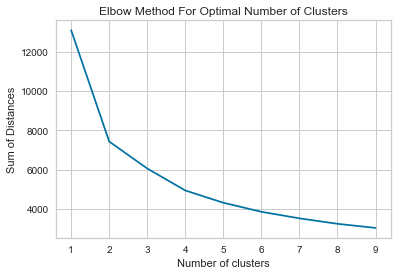

In [44]:
#Manually determining the number of clusters
distances = []
k_values = range(1,10)
for cluster in k_values :
  kmeans = KMeans(n_clusters=cluster)
  kmeans.fit(reduced_df)
  distances.append(kmeans.inertia_)
plt.plot(k_values, distances,'bx-')
plt.xlabel('Number of clusters') 
plt.ylabel('Sum of Distances') 
plt.title('Elbow Method For Optimal Number of Clusters')
plt.show()

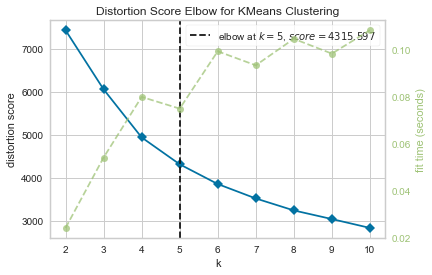

<AxesSubplot: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [45]:
#Using KElbowVisualizer to determine the number of clusters 
auto_elbow = KElbowVisualizer(KMeans(), k=10)
auto_elbow.fit(reduced_df)
auto_elbow.show()

In [46]:
km = KMeans(n_clusters=4)
clusters = km.fit_predict(reduced_df)
pca_clust = reduced_df.copy()
pca_clust['clusters']=clusters
pca_clust.head()

,c1,c2,c3,clusters
0,1.998460,1.645866,1.851690,3
1,-1.538274,-1.875943,-0.773127,2
2,1.370279,-0.006679,-0.550418,1
3,-1.920001,-0.185241,-2.029001,0
4,0.052694,-0.768840,-0.342006,2


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


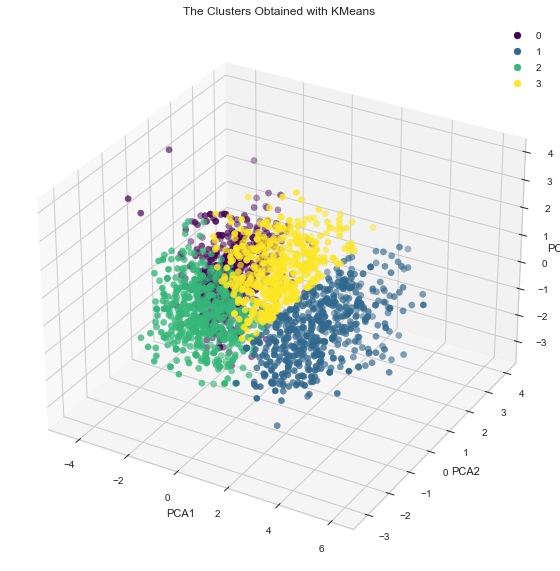

In [47]:

#Plotting the clusters
x=pca_clust['c1']
y=pca_clust['c2']
z=pca_clust['c3']
fig = plt.figure(figsize=(12,10))
ax = plt.subplot(projection='3d')
sc=ax.scatter(x, y, z, s=40, c=pca_clust["clusters"],marker='o' ,cmap=plt.colormaps['viridis'])
ax.legend()
ax.set_title("The Clusters Obtained with KMeans")
ax.set_xlabel('PCA1')
ax.set_ylabel('PCA2')
ax.set_zlabel('PCA3')
plt.legend(*sc.legend_elements())
plt.show()

In [48]:
df['clusters'] = clusters
df.head()

,income,recency,numwebvisits,age,cust_period,has_partner,children,education,expenditures,accepted_offer,num_purchases,clusters
0,58138.0,58,7,57,971,0,0,1,1617,1,25,3
1,46344.0,38,5,60,125,0,2,1,27,0,6,2
2,71613.0,26,4,49,472,1,0,1,776,0,21,1
3,26646.0,26,6,30,65,1,1,1,53,0,8,0
4,58293.0,94,5,33,321,1,1,2,422,0,19,2


### Clustering Method Evalulation:
We will use silhouette_score() to determine how well the clustering was performed.

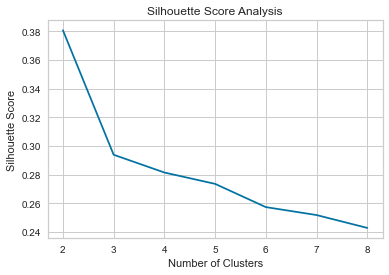

In [49]:
n_clusters = [2, 3, 4, 5, 6, 7, 8]
silhouette= []
for cluster in n_clusters:
 
 # initialise kmeans
  kmeans = KMeans(n_clusters=cluster)
  kmeans.fit(reduced_df)
  labels = kmeans.labels_
 
 # silhouette score
  silhouette.append(silhouette_score(reduced_df, labels, metric='euclidean'))
plt.plot(n_clusters,silhouette)
plt.xlabel('Number of Clusters') 
plt.ylabel('Silhouette Score') 
plt.title('Silhouette Score Analysis')
plt.show()

Silhouette score goes down as we increase the number of clusters. While considering only 2 or 3 clusters may seem like a reasonable option, it would result in an oversimplification of customer features. Five clusters is too many and yield a non-uniform distribution of number of customers in each cluster. By utilizing four clusters, we can gather a more comprehensive understanding of the unique characteristics within each cluster as well as obtain the most uniform distribution in terms of number of customers in each cluster.

### Cluster Statistics:

In [50]:
cluster_data=pd.DataFrame(df.groupby('clusters').agg(np.mean).round(2), columns=df.columns[:-1])
cluster_data['customer_count'] = df.groupby('clusters').agg(np.size)['income']
cluster_data


,income,recency,numwebvisits,age,cust_period,has_partner,children,education,expenditures,accepted_offer,num_purchases,customer_count
clusters,,,,,,,,,,,,
0,30030.44,49.54,7.15,36.95,573.75,0.65,1.03,0.88,116.79,0.20,8.30,612
1,77643.87,48.56,2.50,44.98,464.35,0.62,0.18,1.26,1347.92,1.04,20.44,539
2,44470.63,49.47,5.42,49.39,347.01,0.67,1.47,1.58,174.92,0.12,10.12,556
3,59363.45,48.37,6.01,50.31,670.30,0.64,1.10,1.41,887.17,0.48,22.21,505


In [51]:
cluster_stats = df.groupby('clusters').agg(['mean', 'median', 'std', 'min', 'max']).transpose()

cluster_stats


clusters                          0              1             2             3
income         mean    30030.439542   77643.871985  44470.627698  59363.453465
               median  30096.000000   77044.000000  44367.000000  60093.000000
               std     11144.312101   13364.796494  12394.468953  10787.590264
               min      1730.000000    2447.000000   4428.000000  22507.000000
               max     70829.000000  162397.000000  79146.000000  94871.000000
recency        mean       49.544118      48.564007     49.469424     48.374257
               median     49.000000      49.000000     50.000000     49.000000
               std        29.138526      29.261751     28.958948     28.406497
               min         0.000000       0.000000      0.000000      0.000000
               max        99.000000      99.000000     99.000000     99.000000
numwebvisits   mean        7.150327       2.495362      5.424460      6.007921
               median      7.000000       2.000000      6.000000      6.000000
               std         1.905359       1.456136      1.714710      1.679692
               min         3.000000       0.000000      0.000000      1.000000
               max        20.000000       8.000000      9.000000     10.000000
age            mean       36.952614      44.981447     49.393885     50.312871
               median     36.000000      44.000000     49.000000     50.000000
               std         8.737828      13.356828      9.542200      9.446441
               min        18.000000      19.000000     25.000000     23.000000
               max        67.000000      73.000000     74.000000     71.000000
cust_period    mean      573.751634     464.352505    347.008993    670.304950
               median    598.500000     444.000000    344.000000    680.000000
               std       216.990381     222.542995    175.925112    176.115566
               min         1.000000       1.000000      0.000000    192.000000
               max      1063.000000    1063.000000   1000.000000   1063.000000
has_partner    mean        0.647059       0.617811      0.674460      0.641584
               median      1.000000       1.000000      1.000000      1.000000
               std         0.478276       0.486374      0.468998      0.480011
               min         0.000000       0.000000      0.000000      0.000000
               max         1.000000       1.000000      1.000000      1.000000
children       mean        1.026144       0.183673      1.467626      1.095050
               median      1.000000       0.000000      1.000000      1.000000
               std         0.607619       0.397053      0.715866      0.576383
               min         0.000000       0.000000      0.000000      0.000000
               max         3.000000       2.000000      3.000000      3.000000
education      mean        0.875817       1.263451      1.575540      1.409901
               median      1.000000       1.000000      2.000000      1.000000
               std         0.635247       0.616667      0.529877      0.587824
               min         0.000000       0.000000      0.000000      0.000000
               max         2.000000       2.000000      2.000000      2.000000
expenditures   mean      116.785948    1347.916512    174.922662    887.168317
               median     65.500000    1319.000000     96.000000    859.000000
               std       133.660065     447.793204    172.617933    400.677424
               min         5.000000       6.000000      8.000000    152.000000
               max       839.000000    2525.000000    902.000000   2092.000000
accepted_offer mean        0.200980       1.040816      0.122302      0.477228
               median      0.000000       1.000000      0.000000      0.000000
               std         0.495940       1.312722      0.374126      0.799291
               min         0.000000       0.000000      0.000000      0.000000
               max         3.000000       5.000000

<AxesSubplot: title={'center': 'Number of Customers in Each Cluster'}, xlabel='Clusters', ylabel='Number of Customers'>

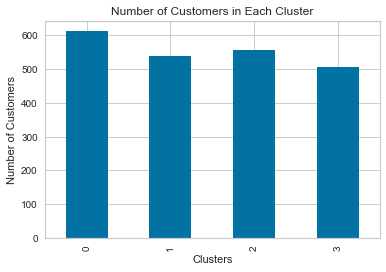

In [52]:
#Distribution of number of customers in each cluster
cluster_data.customer_count.plot(kind='bar', ylabel='Number of Customers', xlabel='Clusters', title="Number of Customers in Each Cluster")

Description of Clusters:
Cluster number zero: The customers in this cluster have the lowest income and education levels. They are the youngest customer segment and are likely to live with a partner, possibly having one or no children. They spend the least amount of money and show the least interest in promotions. They have been shopping at this store for a considerable period of time. Additionally, they are more likely to visit the website compared to any other group. This cluster represents the largest customer segment and can be effectively targeted online with low-priced products that are popular among young people.

Cluster number one: This customer group exhibits the highest income level. They spend the most amount of money, although their number of purchases is not the highest. This indicates their preference for more expensive products. On average, they are around 45 years old and possess a moderate level of education. They are single individuals without children. This group is the most likely to respond to promotions and the least likely to visit the website. Targeting this cluster can be achieved by running promotions on expensive products that are not family-oriented.

Cluster number two: The customers in this cluster have the second-lowest income level. They are the most likely group to live with a partner and have children. On average, their age is almost 50, and they exhibit the highest level of education among all clusters. While they do not spend a significant amount of money, when they do make purchases, they tend to opt for less expensive products. This cluster does not pay much attention to promotions. They have recently started shopping at this store and can be effectively targeted with family-oriented products that are available at discounted prices.

Cluster number three: This group has the second-highest income level. They are the oldest among the clusters and have been loyal customers of this store for the longest period of time. They possess a fair level of education and are likely to live with a partner and children. They have the second-highest overall spending and spending per item. They are receptive to promotions and visit the website more frequently. This cluster can be effectively targeted online with expensive family-oriented products.

In summary, we have identified four distinct clusters: low-income, mostly single young people; high-income older single people; families with low income; and families with high income.